# 2.3 Vectorization Techniques and Model Comparison

**Google Colab Ready** – optimized for GPU acceleration.

This notebook compares three vectorization pipelines for Vietnamese emotion classification:

1. **TF-IDF** → Traditional ML (Logistic Regression, Random Forest, SVM, Naive Bayes)
2. **Tokenization + Padding (Random Init)** → Deep Learning (LSTM, CNN)
3. **Word2Vec Pre-trained Embeddings** → Deep Learning (LSTM, CNN)

### How to Use
1. Upload training data to Google Drive at: `MyDrive/thesis/data/`
   - Required files: `train_processed.csv`, `val_processed.csv`, `test_processed.csv`
2. Enable GPU in Colab: **Runtime → Change runtime type → GPU**
3. Run cells in order

### Key Comparisons
- **TF-IDF**: Traditional bag-of-words approach
- **Random Initialization**: Embeddings learned from scratch during training
- **Word2Vec**: Pre-trained embeddings that capture semantic relationships

---

## 0. Google Colab Setup & Imports

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, subprocess

try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    TPU_AVAILABLE = True
    print("TPU detected and configured")
except ImportError:
    TPU_AVAILABLE = False

gpu_info = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                          capture_output=True, text=True)
if gpu_info.returncode == 0:
    print(f"GPU detected: {gpu_info.stdout.strip()}")
else:
    print("No NVIDIA GPU detected – training will be slow on CPU.")

Mounted at /content/drive
GPU detected: Tesla T4, 15360 MiB


In [2]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow keras gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.5 MB/s eta 0:00:00


In [3]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Conv1D,
    GlobalMaxPooling1D,
    Bidirectional,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from gensim.models import Word2Vec

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU configuration ──
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print(f"GPU(s) detected: {[g.name for g in gpus]}")
    print(f"Mixed-precision policy: {tf.keras.mixed_precision.global_policy().name}")
else:
    print("No GPU detected – running on CPU.")

print(f"TensorFlow version: {tf.__version__}")

# ── Batch sizes ──
TRAIN_BATCH_SIZE = 128
VAL_BATCH_SIZE   = 264
print(f"Train batch size : {TRAIN_BATCH_SIZE}")
print(f"Val/Test batch   : {VAL_BATCH_SIZE}")

GPU(s) detected: ['/physical_device:GPU:0']
Mixed-precision policy: mixed_float16
TensorFlow version: 2.19.0
Train batch size : 128
Val/Test batch   : 264


## 1. Data Loading

Load the pre-processed train / validation / test splits and normalise column names.

In [6]:
DATA_DIR = Path("/content/drive/MyDrive/thesis/data/processed")

TRAIN_FILE = DATA_DIR / "train_final.csv"
VAL_FILE   = DATA_DIR / "val_final.csv"
TEST_FILE  = DATA_DIR / "test_final.csv"

for f in [TRAIN_FILE, VAL_FILE, TEST_FILE]:
    assert f.exists(), f"Missing: {f}"
print(f"Data directory: {DATA_DIR}")

VN_TO_EN = {
    "tức giận": "Anger",
    "khó chịu": "Disgust",
    "vui vẻ": "Enjoyment",
    "sợ hãi": "Fear",
    "khác": "Other",
    "buồn": "Sadness",
    "ngạc nhiên": "Surprise",
}

def load_and_normalise(path: Path) -> pd.DataFrame:
    """Load CSV and normalise to columns: text, label."""
    df = pd.read_csv(path)

    # Pick the best available text column
    if "Sentence_clean" in df.columns:
        df["text"] = df["Sentence_clean"]
    elif "Sentence" in df.columns:
        df["text"] = df["Sentence"]
    else:
        raise ValueError(f"No text column found in {path}")

    # Pick the best available label column
    if "emotion_vn" in df.columns:
        df["label"] = df["Emotion"]
    elif "Emotion" in df.columns:
        df["label"] = df["emotion_vn"].map(VN_TO_EN)
    else:
        raise ValueError(f"No label column found in {path}")

    df = df[["text", "label"]].dropna()
    return df


train_df = load_and_normalise(TRAIN_FILE)
val_df   = load_and_normalise(VAL_FILE)
test_df  = load_and_normalise(TEST_FILE)

print(f"Train : {train_df.shape}")
print(f"Val   : {val_df.shape}")
print(f"Test  : {test_df.shape}")
print(f"\nLabels: {sorted(train_df['label'].unique())}")
train_df.head()

Data directory: /content/drive/MyDrive/thesis/data/processed
Train : (5542, 2)
Val   : (686, 2)
Test  : (692, 2)

Labels: ['Anger', 'Disgust', 'Enjoyment', 'Fear', 'Other', 'Sadness', 'Surprise']


,text,label
0,thính đấy đừng dính . vì ngày nào đấy mày sẽ n...,Disgust
1,tội nghiệp thằng bé cười lớn chúng mày bốc đâu...,Sadness
2,e vừa bị điện cao thế giật hôm chạp . bây giờ ...,Fear
3,không phải crush v nhưng mà nhìn ổng cười mỉm ...,Enjoyment
4,ngôn ngữ gì ngộ nghĩnh vậy,Surprise


In [7]:
le = LabelEncoder()
le.fit(sorted(train_df["label"].unique()))

y_train = le.transform(train_df["label"])
y_val   = le.transform(val_df["label"])
y_test  = le.transform(test_df["label"])

num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Number of classes: 7
Class mapping: {np.str_('Anger'): np.int64(0), np.str_('Disgust'): np.int64(1), np.str_('Enjoyment'): np.int64(2), np.str_('Fear'): np.int64(3), np.str_('Other'): np.int64(4), np.str_('Sadness'): np.int64(5), np.str_('Surprise'): np.int64(6)}


### Label Distribution

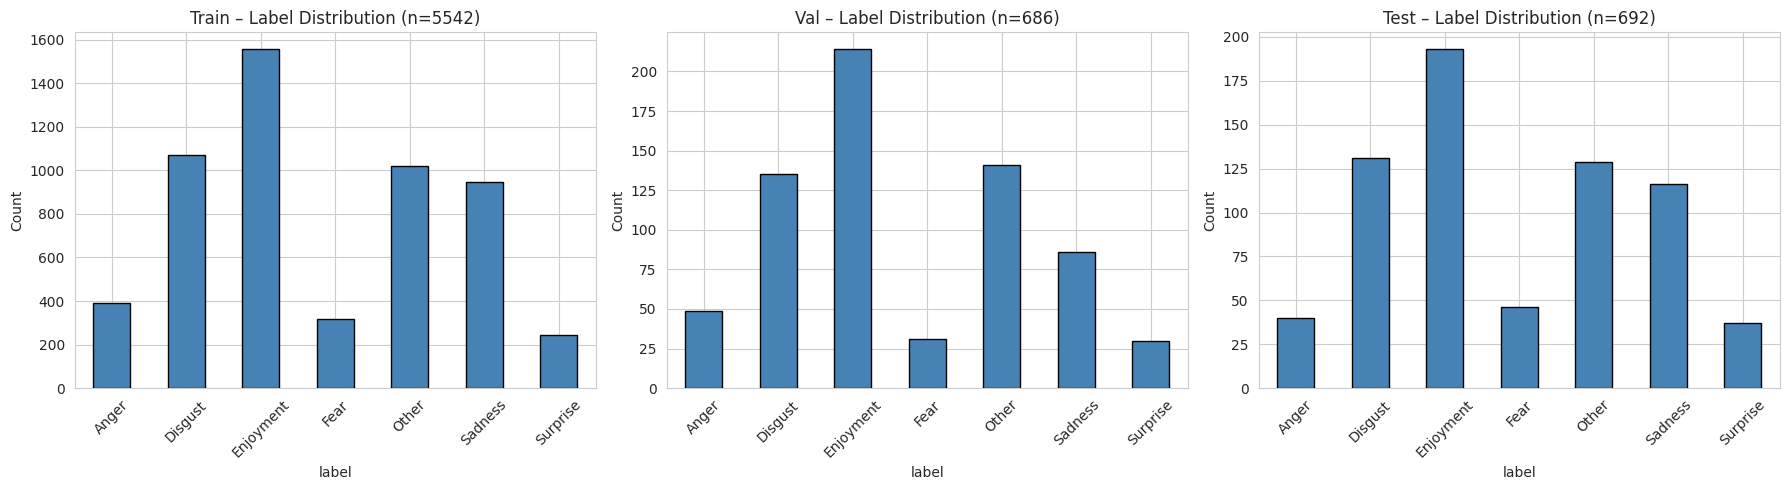

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, df_) in zip(axes, [("Train", train_df), ("Val", val_df), ("Test", test_df)]):
    df_["label"].value_counts().sort_index().plot.bar(ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"{name} – Label Distribution (n={len(df_)})")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---

## 2. Traditional Machine Learning Pipeline

### 2.1 Vectorization: TF-IDF (Term Frequency – Inverse Document Frequency)

`TfidfVectorizer(max_features=5000)` converts raw text into fixed-length numerical vectors
where each dimension corresponds to a word weighted by its importance across the corpus.

In [9]:
tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_val_tfidf   = tfidf.transform(val_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])

print(f"TF-IDF vocabulary size : {len(tfidf.vocabulary_)}")
print(f"X_train_tfidf shape    : {X_train_tfidf.shape}")
print(f"X_val_tfidf shape      : {X_val_tfidf.shape}")
print(f"X_test_tfidf shape     : {X_test_tfidf.shape}")

TF-IDF vocabulary size : 3905
X_train_tfidf shape    : (5542, 3905)
X_val_tfidf shape      : (686, 3905)
X_test_tfidf shape     : (692, 3905)


### 2.2 Model Training & Evaluation

In [10]:
ml_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs", multi_class="multinomial", random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=SEED, n_jobs=-1
    ),
    "SVM (LinearSVC)": LinearSVC(
        C=1.0, max_iter=2000, random_state=SEED
    ),
    "Naive Bayes": MultinomialNB(alpha=1.0),
}

ml_results = []
cv_folds = 5
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)

for name, model in ml_models.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    # Perform 5-fold cross-validation on training data
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_f1_scores = cross_val_score(model, X_train_tfidf, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1)

    print(f"\n5-Fold Cross-Validation Results:")
    print(f"  Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  F1 Score: {cv_f1_scores.mean():.4f} (+/- {cv_f1_scores.std():.4f})")
    print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores]}")

    # Train on full training set for final evaluation
    model.fit(X_train_tfidf, y_train)

    y_val_pred  = model.predict(X_val_tfidf)
    y_test_pred = model.predict(X_test_tfidf)

    val_acc  = accuracy_score(y_val, y_val_pred)
    val_f1   = f1_score(y_val, y_val_pred, average="weighted")
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="weighted")

    print(f"\nValidation  – Accuracy: {val_acc:.4f}  |  F1 (weighted): {val_f1:.4f}")
    print(f"Test        – Accuracy: {test_acc:.4f}  |  F1 (weighted): {test_f1:.4f}")
    print(f"\nTest Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=le.classes_))

    ml_results.append({
        "Model": name,
        "Vectorization": "TF-IDF",
        "CV Accuracy": cv_scores.mean(),
        "CV Accuracy Std": cv_scores.std(),
        "CV F1": cv_f1_scores.mean(),
        "CV F1 Std": cv_f1_scores.std(),
        "Val Accuracy": val_acc,
        "Val F1": val_f1,
        "Test Accuracy": test_acc,
        "Test F1": test_f1,
    })


  Logistic Regression

5-Fold Cross-Validation Results:
  Accuracy: 0.5669 (+/- 0.0102)
  F1 Score: 0.5511 (+/- 0.0076)
  Fold scores: ['0.5744', '0.5528', '0.5821', '0.5632', '0.5623']

Validation  – Accuracy: 0.5860  |  F1 (weighted): 0.5695
Test        – Accuracy: 0.5751  |  F1 (weighted): 0.5596

Test Classification Report:
              precision    recall  f1-score   support

       Anger       0.58      0.17      0.27        40
     Disgust       0.52      0.61      0.56       131
   Enjoyment       0.57      0.75      0.65       193
        Fear       0.88      0.48      0.62        46
       Other       0.50      0.51      0.51       129
     Sadness       0.67      0.63      0.65       116
    Surprise       0.71      0.14      0.23        37

    accuracy                           0.58       692
   macro avg       0.63      0.47      0.50       692
weighted avg       0.59      0.58      0.56       692


  Random Forest

5-Fold Cross-Validation Results:
  Accuracy: 0.5395 (+

### 2.3 Confusion Matrices – Traditional ML

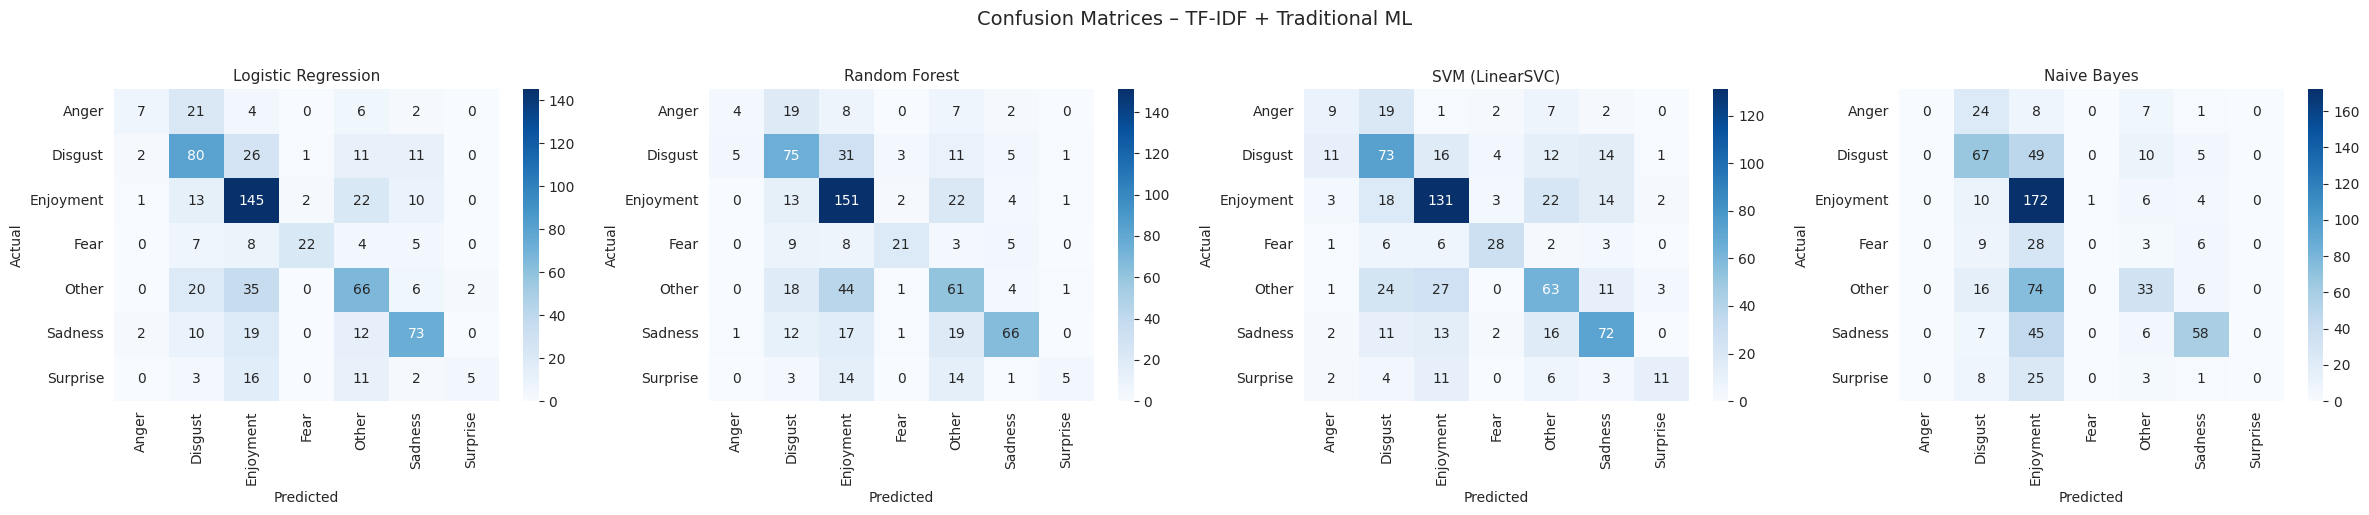

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (name, model) in zip(axes, ml_models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
    )
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices – TF-IDF + Traditional ML", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 3. Deep Learning Pipeline

### 3.1 Vectorization: Tokenization & Padding

`Tokenizer(num_words=max_words)` builds a word-index dictionary from the training corpus.
`texts_to_sequences` maps each sentence to a list of integer IDs.
`pad_sequences` ensures all sequences have the same length for batch processing.

In [12]:
MAX_WORDS   = 5000
MAX_SEQ_LEN = 128
EMBED_DIM   = 128

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["text"])
X_val_seq   = tokenizer.texts_to_sequences(val_df["text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["text"])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_SEQ_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQ_LEN, padding="post", truncating="post")

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

vocab_size = max(MAX_WORDS, len(tokenizer.word_index) + 1)

print(f"Tokenizer word_index size: {len(tokenizer.word_index)}")
print(f"Embedding vocab_size     : {vocab_size}")
print(f"Max sequence length      : {MAX_SEQ_LEN}")
print(f"X_train_pad shape        : {X_train_pad.shape}")
print(f"X_val_pad shape          : {X_val_pad.shape}")
print(f"X_test_pad shape         : {X_test_pad.shape}")
print(f"y_train_cat shape        : {y_train_cat.shape}")

Tokenizer word_index size: 3954
Embedding vocab_size     : 5000
Max sequence length      : 128
X_train_pad shape        : (5542, 128)
X_val_pad shape          : (686, 128)
X_test_pad shape         : (692, 128)
y_train_cat shape        : (5542, 7)


### 3.2 Sequence Length Distribution

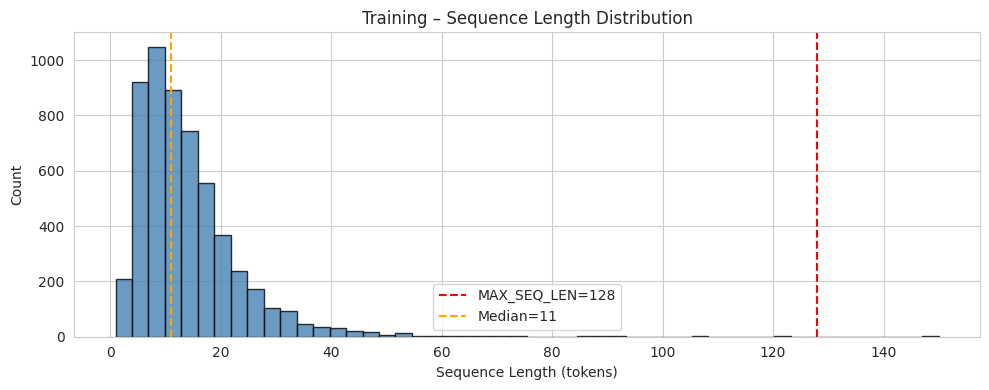

100.0% of training sequences fit within MAX_SEQ_LEN=128

Tokenizer vocabulary (top 20 words):
     1: <OOV>
     2: cười
     3: không
     4: lớn
     5: tao
     6: là
     7: có
     8: mà
     9: này
    10: nó
    11: đi
    12: người
    13: thì
    14: con
    15: rồi
    16: cái
    17: cho
    18: per
    19: được
    20: cũng


In [13]:
seq_lengths = [len(s) for s in X_train_seq]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lengths, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(MAX_SEQ_LEN, color="red", linestyle="--", label=f"MAX_SEQ_LEN={MAX_SEQ_LEN}")
ax.axvline(np.median(seq_lengths), color="orange", linestyle="--", label=f"Median={np.median(seq_lengths):.0f}")
ax.set_title("Training – Sequence Length Distribution")
ax.set_xlabel("Sequence Length (tokens)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

pct_within = np.mean([l <= MAX_SEQ_LEN for l in seq_lengths]) * 100
print(f"{pct_within:.1f}% of training sequences fit within MAX_SEQ_LEN={MAX_SEQ_LEN}")

print(f"\nTokenizer vocabulary (top 20 words):")
word_freq = sorted(tokenizer.word_index.items(), key=lambda x: x[1])[:20]
for word, idx in word_freq:
    print(f"  {idx:4d}: {word}")

---

## 3.3 Vectorization: Word2Vec Pre-trained Embeddings

Word2Vec learns dense vector representations of words by training on the corpus.
Unlike random initialization, these embeddings capture semantic relationships between words.

We train Word2Vec on the training corpus and create an embedding matrix to initialize the Embedding layer.

In [14]:
# Tokenize text into words for Word2Vec training
def tokenize_text(text):
    """Simple word tokenization by splitting on whitespace."""
    return text.lower().split()

train_sentences = [tokenize_text(text) for text in train_df["text"]]

print(f"Training Word2Vec on {len(train_sentences)} sentences...")
print(f"Example tokenized sentence: {train_sentences[0][:10]}")

# Train Word2Vec model
# vector_size: dimensionality of word vectors (same as EMBED_DIM)
# window: maximum distance between current and predicted word
# min_count: ignore words with frequency lower than this
# workers: number of CPU cores for training
# sg: training algorithm (0=CBOW, 1=Skip-gram)
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=EMBED_DIM,
    window=5,
    min_count=2,
    workers=4,
    sg=1,  # Skip-gram
    epochs=10,
    seed=SEED,
)

print(f"\nWord2Vec training complete!")
print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Vector dimension: {w2v_model.wv.vector_size}")

# Show some word similarities
test_words = ["vui", "buồn", "tốt", "xấu"]
print(f"\nWord similarities (if words exist in vocabulary):")
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"  {word}: {', '.join([f'{w}({s:.2f})' for w, s in similar])}")
    else:
        print(f"  {word}: not in vocabulary")

Training Word2Vec on 5542 sentences...
Example tokenized sentence: ['thính', 'đấy', 'đừng', 'dính', '.', 'vì', 'ngày', 'nào', 'đấy', 'mày']

Word2Vec training complete!
Vocabulary size: 2607
Vector dimension: 128

Word similarities (if words exist in vocabulary):
  vui: vẻ(0.92), the(0.85), thú(0.84)
  buồn: bã(0.87), nôn(0.78), tệ(0.76)
  tốt: trân(0.82), sếp(0.82), điều(0.80)
  xấu: ui(0.90), roi(0.89), hổ(0.89)


In [15]:
# Create embedding matrix from Word2Vec model
# The matrix maps word indices (from tokenizer) to Word2Vec vectors
embedding_matrix_w2v = np.zeros((vocab_size, EMBED_DIM))
words_found = 0
words_not_found = 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix_w2v[idx] = w2v_model.wv[word]
        words_found += 1
    else:
        # Words not in Word2Vec vocabulary will have zero vectors
        words_not_found += 1

print(f"\nEmbedding Matrix Statistics:")
print(f"  Shape: {embedding_matrix_w2v.shape}")
print(f"  Words found in Word2Vec: {words_found}")
print(f"  Words not found (zero vectors): {words_not_found}")
print(f"  Coverage: {words_found / (words_found + words_not_found) * 100:.2f}%")
print(f"  Non-zero vectors: {np.count_nonzero(np.any(embedding_matrix_w2v != 0, axis=1))}")

# Verify embedding matrix
sample_idx = 1  # Index for first word
sample_word = [w for w, i in tokenizer.word_index.items() if i == sample_idx][0] if sample_idx in [i for _, i in tokenizer.word_index.items()] else None
if sample_word:
    print(f"\nSample: word '{sample_word}' (index={sample_idx})")
    print(f"  Embedding vector (first 10 dims): {embedding_matrix_w2v[sample_idx][:10]}")


Embedding Matrix Statistics:
  Shape: (5000, 128)
  Words found in Word2Vec: 2595
  Words not found (zero vectors): 1359
  Coverage: 65.63%
  Non-zero vectors: 2595

Sample: word '<OOV>' (index=1)
  Embedding vector (first 10 dims): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 3.4 LSTM with Word2Vec Embeddings

Initialize the Embedding layer with Word2Vec pre-trained weights.
Set `trainable=True` to allow fine-tuning during training.

In [ ]:
# Shared helpers for deep-learning training visualization and evaluation.
# Defined here so they are available to every DL section below (Word2Vec LSTM/CNN,
# random-embedding LSTM/CNN, etc.) regardless of execution order.
def plot_training_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history["accuracy"], label="Train")
    ax1.plot(history.history["val_accuracy"], label="Val")
    ax1.set_title(f"{title} – Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="Train")
    ax2.plot(history.history["val_loss"], label="Val")
    ax2.set_title(f"{title} – Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()


def evaluate_dl_model(model, X_pad, y_true, le, model_name):
    y_prob = model.predict(X_pad, batch_size=VAL_BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{model_name} – Test Results")
    print(f"Accuracy: {acc:.4f}  |  F1 (weighted): {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    return acc, f1, y_pred


In [16]:
def build_lstm_w2v(vocab_size, embed_dim, max_len, num_classes, embedding_matrix):
    """Build LSTM with pre-trained Word2Vec embeddings."""
    model = Sequential([
        Embedding(
            vocab_size,
            embed_dim,
            input_length=max_len,
            weights=[embedding_matrix],
            trainable=True  # Allow fine-tuning
        ),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, dtype="float32", activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


lstm_w2v_model = build_lstm_w2v(vocab_size, EMBED_DIM, MAX_SEQ_LEN, num_classes, embedding_matrix_w2v)
lstm_w2v_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,000 (2.44 MB)

 Trainable params: 640,000 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# 5-Fold Cross-Validation for LSTM with Word2Vec
print(f"\n{'='*60}")
print(f"  LSTM (Word2Vec) - 5-Fold Cross-Validation")
print(f"{'='*60}\n")

lstm_w2v_cv_scores = []
lstm_w2v_cv_f1_scores = []
EPOCHS = 30

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_pad, y_train), 1):
    print(f"Training Fold {fold}/5...")

    X_fold_train, X_fold_val = X_train_pad[train_idx], X_train_pad[val_idx]
    y_fold_train, y_fold_val = y_train_cat[train_idx], y_train_cat[val_idx]

    fold_model = build_lstm_w2v(vocab_size, EMBED_DIM, MAX_SEQ_LEN, num_classes, embedding_matrix_w2v)

    fold_history = fold_model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=EPOCHS,
        batch_size=TRAIN_BATCH_SIZE,
        validation_batch_size=VAL_BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
    )

    fold_val_loss, fold_val_acc = fold_model.evaluate(X_fold_val, y_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0)
    y_fold_pred = np.argmax(fold_model.predict(X_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0), axis=1)
    y_fold_true = np.argmax(y_fold_val, axis=1)
    fold_val_f1 = f1_score(y_fold_true, y_fold_pred, average="weighted")

    lstm_w2v_cv_scores.append(fold_val_acc)
    lstm_w2v_cv_f1_scores.append(fold_val_f1)

    print(f"  Fold {fold} - Accuracy: {fold_val_acc:.4f}, F1: {fold_val_f1:.4f}")

lstm_w2v_cv_scores = np.array(lstm_w2v_cv_scores)
lstm_w2v_cv_f1_scores = np.array(lstm_w2v_cv_f1_scores)

print(f"\n5-Fold Cross-Validation Results:")
print(f"  Accuracy: {lstm_w2v_cv_scores.mean():.4f} (+/- {lstm_w2v_cv_scores.std():.4f})")
print(f"  F1 Score: {lstm_w2v_cv_f1_scores.mean():.4f} (+/- {lstm_w2v_cv_f1_scores.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in lstm_w2v_cv_scores]}")

# Train final model on full training set
print(f"\nTraining final LSTM (Word2Vec) model on full training set...")
lstm_w2v_history = lstm_w2v_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=TRAIN_BATCH_SIZE,
    validation_batch_size=VAL_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

plot_training_history(lstm_w2v_history, "Bi-LSTM (Word2Vec)")


  LSTM (Word2Vec) - 5-Fold Cross-Validation

Training Fold 1/5...
  Fold 1 - Accuracy: 0.5518, F1: 0.5240
Training Fold 2/5...
  Fold 2 - Accuracy: 0.3463, F1: 0.2447
Training Fold 3/5...


  Fold 3 - Accuracy: 0.4215, F1: 0.3272
Training Fold 4/5...
  Fold 4 - Accuracy: 0.4332, F1: 0.3750
Training Fold 5/5...
  Fold 5 - Accuracy: 0.3078, F1: 0.1771

5-Fold Cross-Validation Results:
  Accuracy: 0.4121 (+/- 0.0840)
  F1 Score: 0.3296 (+/- 0.1186)
  Fold scores: ['0.5518', '0.3463', '0.4215', '0.4332', '0.3078']

Training final LSTM (Word2Vec) model on full training set...
Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.2672 - loss: 1.8053 - val_accuracy: 0.3921 - val_loss: 1.6602 - learning_rate: 0.0010
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4177 - loss: 1.5782 - val_accuracy: 0.4534 - val_loss: 1.4673 - learning_rate: 0.0010
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4982 - loss: 1.4075 - val_accuracy: 0.4971 - val_loss: 1.3830 - learning_rate: 5.0000e-04
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5303 - loss: 1.3138 - val_accuracy: 0.5117 - val_loss: 1.3521 - learning_rate: 5.0000e-04


NameError: name 'plot_training_history' is not defined

In [ ]:
lstm_w2v_test_acc, lstm_w2v_test_f1, lstm_w2v_preds = evaluate_dl_model(
    lstm_w2v_model, X_test_pad, y_test, le, "Bi-LSTM (Word2Vec)"
)

lstm_w2v_val_loss, lstm_w2v_val_acc = lstm_w2v_model.evaluate(X_val_pad, y_val_cat, batch_size=VAL_BATCH_SIZE, verbose=0)
lstm_w2v_val_f1 = f1_score(y_val, np.argmax(lstm_w2v_model.predict(X_val_pad, batch_size=VAL_BATCH_SIZE, verbose=0), axis=1), average="weighted")

print(f"\nLSTM (Word2Vec) Cross-Validation Summary:")
print(f"  CV Accuracy: {lstm_w2v_cv_scores.mean():.4f} (+/- {lstm_w2v_cv_scores.std():.4f})")
print(f"  CV F1: {lstm_w2v_cv_f1_scores.mean():.4f} (+/- {lstm_w2v_cv_f1_scores.std():.4f})")

### 3.5 CNN with Word2Vec Embeddings

In [ ]:
def build_cnn_w2v(vocab_size, embed_dim, max_len, num_classes, embedding_matrix):
    """Build CNN with pre-trained Word2Vec embeddings."""
    model = Sequential([
        Embedding(
            vocab_size,
            embed_dim,
            input_length=max_len,
            weights=[embedding_matrix],
            trainable=True  # Allow fine-tuning
        ),
        Conv1D(128, kernel_size=5, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, dtype="float32", activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


cnn_w2v_model = build_cnn_w2v(vocab_size, EMBED_DIM, MAX_SEQ_LEN, num_classes, embedding_matrix_w2v)
cnn_w2v_model.summary()

In [ ]:
# 5-Fold Cross-Validation for CNN with Word2Vec
print(f"\n{'='*60}")
print(f"  CNN (Word2Vec) - 5-Fold Cross-Validation")
print(f"{'='*60}\n")

cnn_w2v_cv_scores = []
cnn_w2v_cv_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_pad, y_train), 1):
    print(f"Training Fold {fold}/5...")

    X_fold_train, X_fold_val = X_train_pad[train_idx], X_train_pad[val_idx]
    y_fold_train, y_fold_val = y_train_cat[train_idx], y_train_cat[val_idx]

    fold_model = build_cnn_w2v(vocab_size, EMBED_DIM, MAX_SEQ_LEN, num_classes, embedding_matrix_w2v)

    fold_history = fold_model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=EPOCHS,
        batch_size=TRAIN_BATCH_SIZE,
        validation_batch_size=VAL_BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
    )

    fold_val_loss, fold_val_acc = fold_model.evaluate(X_fold_val, y_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0)
    y_fold_pred = np.argmax(fold_model.predict(X_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0), axis=1)
    y_fold_true = np.argmax(y_fold_val, axis=1)
    fold_val_f1 = f1_score(y_fold_true, y_fold_pred, average="weighted")

    cnn_w2v_cv_scores.append(fold_val_acc)
    cnn_w2v_cv_f1_scores.append(fold_val_f1)

    print(f"  Fold {fold} - Accuracy: {fold_val_acc:.4f}, F1: {fold_val_f1:.4f}")

cnn_w2v_cv_scores = np.array(cnn_w2v_cv_scores)
cnn_w2v_cv_f1_scores = np.array(cnn_w2v_cv_f1_scores)

print(f"\n5-Fold Cross-Validation Results:")
print(f"  Accuracy: {cnn_w2v_cv_scores.mean():.4f} (+/- {cnn_w2v_cv_scores.std():.4f})")
print(f"  F1 Score: {cnn_w2v_cv_f1_scores.mean():.4f} (+/- {cnn_w2v_cv_f1_scores.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in cnn_w2v_cv_scores]}")

# Train final model on full training set
print(f"\nTraining final CNN (Word2Vec) model on full training set...")
cnn_w2v_history = cnn_w2v_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=TRAIN_BATCH_SIZE,
    validation_batch_size=VAL_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

plot_training_history(cnn_w2v_history, "CNN (Word2Vec)")

In [ ]:
cnn_w2v_test_acc, cnn_w2v_test_f1, cnn_w2v_preds = evaluate_dl_model(
    cnn_w2v_model, X_test_pad, y_test, le, "CNN (Word2Vec)"
)

cnn_w2v_val_loss, cnn_w2v_val_acc = cnn_w2v_model.evaluate(X_val_pad, y_val_cat, batch_size=VAL_BATCH_SIZE, verbose=0)
cnn_w2v_val_f1 = f1_score(y_val, np.argmax(cnn_w2v_model.predict(X_val_pad, batch_size=VAL_BATCH_SIZE, verbose=0), axis=1), average="weighted")

print(f"\nCNN (Word2Vec) Cross-Validation Summary:")
print(f"  CV Accuracy: {cnn_w2v_cv_scores.mean():.4f} (+/- {cnn_w2v_cv_scores.std():.4f})")
print(f"  CV F1: {cnn_w2v_cv_f1_scores.mean():.4f} (+/- {cnn_w2v_cv_f1_scores.std():.4f})")


### 3.6 LSTM Model (Random Embedding Initialization)

In [ ]:
def build_lstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, dtype="float32", activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


lstm_model = build_lstm(vocab_size, EMBED_DIM, MAX_SEQ_LEN, num_classes)
lstm_model.summary()

In [ ]:
EPOCHS = 30

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

# 5-Fold Cross-Validation for LSTM
print(f"\n{'='*60}")
print(f"  LSTM - 5-Fold Cross-Validation")
print(f"{'='*60}\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lstm_cv_scores = []
lstm_cv_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_pad, y_train), 1):
    print(f"Training Fold {fold}/5...")

    X_fold_train, X_fold_val = X_train_pad[train_idx], X_train_pad[val_idx]
    y_fold_train, y_fold_val = y_train_cat[train_idx], y_train_cat[val_idx]

    fold_model = build_lstm(vocab_size, EMBED_DIM, MAX_SEQ_LEN, num_classes)

    fold_history = fold_model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=EPOCHS,
        batch_size=TRAIN_BATCH_SIZE,
        validation_batch_size=VAL_BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
    )

    fold_val_loss, fold_val_acc = fold_model.evaluate(X_fold_val, y_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0)
    y_fold_pred = np.argmax(fold_model.predict(X_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0), axis=1)
    y_fold_true = np.argmax(y_fold_val, axis=1)
    fold_val_f1 = f1_score(y_fold_true, y_fold_pred, average="weighted")

    lstm_cv_scores.append(fold_val_acc)
    lstm_cv_f1_scores.append(fold_val_f1)

    print(f"  Fold {fold} - Accuracy: {fold_val_acc:.4f}, F1: {fold_val_f1:.4f}")

lstm_cv_scores = np.array(lstm_cv_scores)
lstm_cv_f1_scores = np.array(lstm_cv_f1_scores)

print(f"\n5-Fold Cross-Validation Results:")
print(f"  Accuracy: {lstm_cv_scores.mean():.4f} (+/- {lstm_cv_scores.std():.4f})")
print(f"  F1 Score: {lstm_cv_f1_scores.mean():.4f} (+/- {lstm_cv_f1_scores.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in lstm_cv_scores]}")

# Train final model on full training set
print(f"\nTraining final LSTM model on full training set...")
lstm_history = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=TRAIN_BATCH_SIZE,
    validation_batch_size=VAL_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

In [ ]:
def plot_training_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history["accuracy"], label="Train")
    ax1.plot(history.history["val_accuracy"], label="Val")
    ax1.set_title(f"{title} – Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="Train")
    ax2.plot(history.history["val_loss"], label="Val")
    ax2.set_title(f"{title} – Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()


plot_training_history(lstm_history, "Bi-LSTM")

In [ ]:
def evaluate_dl_model(model, X_pad, y_true, le, model_name):
    y_prob = model.predict(X_pad, batch_size=VAL_BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{model_name} – Test Results")
    print(f"Accuracy: {acc:.4f}  |  F1 (weighted): {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    return acc, f1, y_pred


lstm_test_acc, lstm_test_f1, lstm_preds = evaluate_dl_model(
    lstm_model, X_test_pad, y_test, le, "Bi-LSTM"
)

lstm_val_loss, lstm_val_acc = lstm_model.evaluate(X_val_pad, y_val_cat, batch_size=VAL_BATCH_SIZE, verbose=0)
lstm_val_f1 = f1_score(y_val, np.argmax(lstm_model.predict(X_val_pad, batch_size=VAL_BATCH_SIZE, verbose=0), axis=1), average="weighted")

print(f"\nLSTM Cross-Validation Summary:")
print(f"  CV Accuracy: {lstm_cv_scores.mean():.4f} (+/- {lstm_cv_scores.std():.4f})")
print(f"  CV F1: {lstm_cv_f1_scores.mean():.4f} (+/- {lstm_cv_f1_scores.std():.4f})")

### 3.7 CNN Model (Random Embedding Initialization)

In [ ]:
def build_cnn(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        Conv1D(128, kernel_size=5, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, dtype="float32", activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


cnn_model = build_cnn(vocab_size, EMBED_DIM, MAX_SEQ_LEN, num_classes)
cnn_model.summary()

In [ ]:
# 5-Fold Cross-Validation for CNN
print(f"\n{'='*60}")
print(f"  CNN - 5-Fold Cross-Validation")
print(f"{'='*60}\n")

cnn_cv_scores = []
cnn_cv_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_pad, y_train), 1):
    print(f"Training Fold {fold}/5...")

    X_fold_train, X_fold_val = X_train_pad[train_idx], X_train_pad[val_idx]
    y_fold_train, y_fold_val = y_train_cat[train_idx], y_train_cat[val_idx]

    fold_model = build_cnn(vocab_size, EMBED_DIM, MAX_SEQ_LEN, num_classes)

    fold_history = fold_model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=EPOCHS,
        batch_size=TRAIN_BATCH_SIZE,
        validation_batch_size=VAL_BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
    )

    fold_val_loss, fold_val_acc = fold_model.evaluate(X_fold_val, y_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0)
    y_fold_pred = np.argmax(fold_model.predict(X_fold_val, batch_size=VAL_BATCH_SIZE, verbose=0), axis=1)
    y_fold_true = np.argmax(y_fold_val, axis=1)
    fold_val_f1 = f1_score(y_fold_true, y_fold_pred, average="weighted")

    cnn_cv_scores.append(fold_val_acc)
    cnn_cv_f1_scores.append(fold_val_f1)

    print(f"  Fold {fold} - Accuracy: {fold_val_acc:.4f}, F1: {fold_val_f1:.4f}")

cnn_cv_scores = np.array(cnn_cv_scores)
cnn_cv_f1_scores = np.array(cnn_cv_f1_scores)

print(f"\n5-Fold Cross-Validation Results:")
print(f"  Accuracy: {cnn_cv_scores.mean():.4f} (+/- {cnn_cv_scores.std():.4f})")
print(f"  F1 Score: {cnn_cv_f1_scores.mean():.4f} (+/- {cnn_cv_f1_scores.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in cnn_cv_scores]}")

# Train final model on full training set
print(f"\nTraining final CNN model on full training set...")
cnn_history = cnn_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=TRAIN_BATCH_SIZE,
    validation_batch_size=VAL_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

plot_training_history(cnn_history, "CNN")

In [ ]:
cnn_test_acc, cnn_test_f1, cnn_preds = evaluate_dl_model(
    cnn_model, X_test_pad, y_test, le, "CNN"
)

cnn_val_loss, cnn_val_acc = cnn_model.evaluate(X_val_pad, y_val_cat, batch_size=VAL_BATCH_SIZE, verbose=0)
cnn_val_f1 = f1_score(y_val, np.argmax(cnn_model.predict(X_val_pad, batch_size=VAL_BATCH_SIZE, verbose=0), axis=1), average="weighted")

print(f"\nCNN Cross-Validation Summary:")
print(f"  CV Accuracy: {cnn_cv_scores.mean():.4f} (+/- {cnn_cv_scores.std():.4f})")
print(f"  CV F1: {cnn_cv_f1_scores.mean():.4f} (+/- {cnn_cv_f1_scores.std():.4f})")

### 3.8 Confusion Matrices – Deep Learning

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

models_to_plot = [
    ("Bi-LSTM (Random)", lstm_preds),
    ("CNN (Random)", cnn_preds),
    ("Bi-LSTM (Word2Vec)", lstm_w2v_preds),
    ("CNN (Word2Vec)", cnn_w2v_preds),
]

for idx, (name, preds) in enumerate(models_to_plot):
    ax = axes[idx]
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Oranges",
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
    )
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices – Deep Learning (Random vs Word2Vec Embeddings)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

---

## 4. Overall Model Comparison

In [ ]:
dl_results = [
    {
        "Model": "Bi-LSTM",
        "Vectorization": "Tokenization + Padding",
        "CV Accuracy": lstm_cv_scores.mean(),
        "CV Accuracy Std": lstm_cv_scores.std(),
        "CV F1": lstm_cv_f1_scores.mean(),
        "CV F1 Std": lstm_cv_f1_scores.std(),
        "Val Accuracy": lstm_val_acc,
        "Val F1": lstm_val_f1,
        "Test Accuracy": lstm_test_acc,
        "Test F1": lstm_test_f1,
    },
    {
        "Model": "CNN",
        "Vectorization": "Tokenization + Padding",
        "CV Accuracy": cnn_cv_scores.mean(),
        "CV Accuracy Std": cnn_cv_scores.std(),
        "CV F1": cnn_cv_f1_scores.mean(),
        "CV F1 Std": cnn_cv_f1_scores.std(),
        "Val Accuracy": cnn_val_acc,
        "Val F1": cnn_val_f1,
        "Test Accuracy": cnn_test_acc,
        "Test F1": cnn_test_f1,
    },
    {
        "Model": "Bi-LSTM (Word2Vec)",
        "Vectorization": "Word2Vec",
        "CV Accuracy": lstm_w2v_cv_scores.mean(),
        "CV Accuracy Std": lstm_w2v_cv_scores.std(),
        "CV F1": lstm_w2v_cv_f1_scores.mean(),
        "CV F1 Std": lstm_w2v_cv_f1_scores.std(),
        "Val Accuracy": lstm_w2v_val_acc,
        "Val F1": lstm_w2v_val_f1,
        "Test Accuracy": lstm_w2v_test_acc,
        "Test F1": lstm_w2v_test_f1,
    },
    {
        "Model": "CNN (Word2Vec)",
        "Vectorization": "Word2Vec",
        "CV Accuracy": cnn_w2v_cv_scores.mean(),
        "CV Accuracy Std": cnn_w2v_cv_scores.std(),
        "CV F1": cnn_w2v_cv_f1_scores.mean(),
        "CV F1 Std": cnn_w2v_cv_f1_scores.std(),
        "Val Accuracy": cnn_w2v_val_acc,
        "Val F1": cnn_w2v_val_f1,
        "Test Accuracy": cnn_w2v_test_acc,
        "Test F1": cnn_w2v_test_f1,
    },
]

all_results = pd.DataFrame(ml_results + dl_results)
all_results = all_results.sort_values("Test F1", ascending=False).reset_index(drop=True)

for col in ["CV Accuracy", "CV Accuracy Std", "CV F1", "CV F1 Std", "Val Accuracy", "Val F1", "Test Accuracy", "Test F1"]:
    all_results[col] = all_results[col].map(lambda x: round(x, 4))

print("\n" + "=" * 80)
print("  MODEL COMPARISON – Sorted by Test F1 (weighted)")
print("=" * 80)
all_results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Define colors for each vectorization technique
color_map = {
    "TF-IDF": "#4C72B0",
    "Tokenization + Padding": "#DD8452",
    "Word2Vec": "#55A868"
}
colors = [color_map[v] for v in all_results["Vectorization"]]

axes[0].barh(all_results["Model"], all_results["Test Accuracy"], color=colors, edgecolor="black")
axes[0].set_xlabel("Test Accuracy")
axes[0].set_title("Test Accuracy by Model")
axes[0].set_xlim(0, 1)
for i, v in enumerate(all_results["Test Accuracy"]):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=9)

axes[1].barh(all_results["Model"], all_results["Test F1"], color=colors, edgecolor="black")
axes[1].set_xlabel("Test F1 (weighted)")
axes[1].set_title("Test F1 (weighted) by Model")
axes[1].set_xlim(0, 1)
for i, v in enumerate(all_results["Test F1"]):
    axes[1].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", edgecolor="black", label="TF-IDF (Traditional ML)"),
    Patch(facecolor="#DD8452", edgecolor="black", label="Tokenization+Padding (Random Init)"),
    Patch(facecolor="#55A868", edgecolor="black", label="Word2Vec (Pre-trained)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.08))

plt.suptitle("Vectorization Technique Comparison", fontsize=14)
plt.tight_layout()
plt.show()

---

## 5. Summary

| Pipeline | Vectorization | Models | Key Characteristic |
|---|---|---|---|
| Traditional ML | TF-IDF (`max_features=5000`) | LR, RF, SVM, NB | Bag-of-words; fast training; no sequence awareness |
| Deep Learning (Random Init) | Tokenization + Padding (`num_words=5000`, `maxlen=128`) | Bi-LSTM, CNN | Learns word embeddings from scratch; captures sequential / local patterns |
| Deep Learning (Pre-trained) | Word2Vec (`vector_size=128`, `window=5`, `sg=1`) | Bi-LSTM, CNN | Uses pre-trained embeddings; captures semantic relationships; fine-tuned during training |

### Key Findings

**Word2Vec vs Random Initialization:**
- Word2Vec embeddings are trained on the corpus using Skip-gram algorithm
- Pre-trained embeddings provide better initialization than random weights
- Word2Vec captures semantic relationships between words (e.g., similar words have similar vectors)
- Embeddings are fine-tuned during training to adapt to the specific task

### Cross-Validation
All models were evaluated using **5-fold stratified cross-validation** on the training set to ensure robust performance estimates. The CV scores (mean ± std) provide insight into model stability and generalization capability before final test evaluation.